# LiDAR-only baseline — results

**Presentation notebook — loads the trained artifacts and renders results; it does not train.** Produce them first via `training.ipynb` with `MODEL = "lidar"`.

## 0. Setup

In [1]:
# Repo-root bootstrap — lets this notebook run from notebooks/ or the repo root.
import os, sys
from pathlib import Path
_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "globals.py").exists())
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("repo root:", _ROOT)

repo root: /home/leonardo/Desktop/AIRO/stereo-lidar-perception


In [ ]:
import os
from pathlib import Path
import data  # noqa: F401
_REPO = Path(data.__file__).resolve().parent
os.environ.setdefault("PY123D_DATA_ROOT", str(_REPO / "data"))
os.environ.setdefault("KITTI360_DATA_ROOT", str(_REPO / "KITTI-360"))

import json
import matplotlib.pyplot as plt
import torch

import globals as G
import utils
from data import Py123dDataset, stereo_cache_root
from evaluation import CenterPointDecoder, load_report, print_ap_report
from network import StereoBEVConfig, build_detector
import igev_matcher  # noqa: F401

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL = "lidar"
TAG = ""
CKPT = f"checkpoints/{MODEL}{TAG}.pt"
RESULTS = f"results/{MODEL}{TAG}.json"
HISTORY = f"results/{MODEL}{TAG}_history.json"
FIGDIR = Path("docs/img"); FIGDIR.mkdir(parents=True, exist_ok=True)
print("device:", DEVICE, "| model:", MODEL, "| classes:", G.CLASSES)

/home/leonardo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


device: cuda | model: lidar | classes: ('VEHICLE', 'PERSON', 'TWO_WHEELER', 'TRAFFIC_SIGN', 'TRAIN')


## 1. Training loss curves

In [3]:
if not Path(HISTORY).exists():
    print(f"no {HISTORY} — (re)run training.ipynb §6 with the current notebook to "
          "save the loss curves (§6 calls save_history).")
else:
    history = json.loads(Path(HISTORY).read_text())
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(history["steps"], alpha=0.6); ax[0].set_yscale("log")
    ax[0].set_title(f"{MODEL} — per-step loss"); ax[0].set_xlabel("step"); ax[0].grid(alpha=0.25)
    ax[1].plot(history["train"], "o-", label="train"); ax[1].plot(history["val"], "s-", label="val")
    ax[1].set_title(f"{MODEL} — per-epoch mean loss"); ax[1].set_xlabel("epoch")
    ax[1].legend(); ax[1].grid(alpha=0.25)
    fig.tight_layout(); fig.savefig(FIGDIR / f"{MODEL}{TAG}_loss.png", dpi=90, bbox_inches="tight")
    plt.show()

no results/lidar_history.json — (re)run training.ipynb §6 with the current notebook to save the loss curves (§6 calls save_history).


## 2. Detection AP (per class · 0.5/1/2/4 m)

In [4]:
report = load_report(RESULTS)
print_ap_report(report)
print(f"\nHEADLINE  mAP {report['mAP']:.3f}  |  macro F1 {report['f1']:.3f} "
      f"@{report['op_threshold_m']:g} m  |  mean centre err {report['mean_error_m']:.3f} m")

class         AP@0.5  AP@1    AP@2    AP@4      mean   n_gt
-----------------------------------------------------------
VEHICLE       0.419   0.551   0.588   0.613   0.543  15975
PERSON        0.150   0.152   0.154   0.168   0.156  2911
TWO_WHEELER   0.122   0.141   0.145   0.153   0.140  2090
TRAFFIC_SIGN  0.255   0.260   0.269   0.295   0.269  1503
TRAIN         0.000   0.000   0.000   0.000   0.000  112

F1-optimal operating point @2 m (apply 'confidence >= score' at deployment):
class         prec    recall  F1      score   
----------------------------------------------
VEHICLE       0.589   0.557   0.573   0.268   
PERSON        0.246   0.321   0.279   0.132   
TWO_WHEELER   0.257   0.237   0.247   0.147   
TRAFFIC_SIGN  0.479   0.253   0.331   0.218   
TRAIN         0.000   0.000   0.000   nan     

mAP 0.222 | macro P 0.314 R 0.274 F1 0.286 @2 m | mean centre error (TP@2m) 0.468 m | 3026 frames

HEADLINE  mAP 0.222  |  macro F1 0.286 @2 m  |  mean centre err 0.468 m


## 3. Diagnostics — PR, F1-vs-confidence, confusion

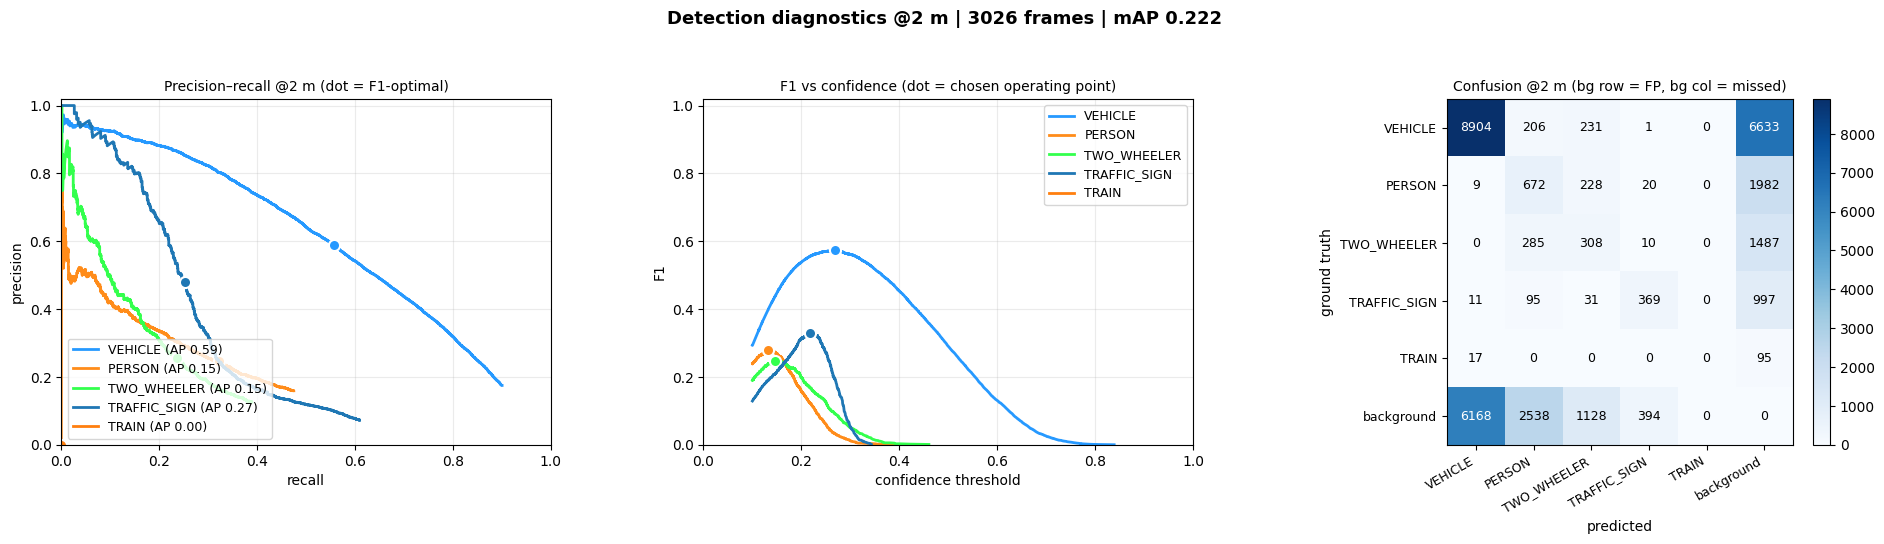

In [5]:
utils.visualize_evaluation(report, save_path=str(FIGDIR / f"{MODEL}{TAG}_diagnostics.png"))
utils.visualize_evaluation(report)

## 4. Qualitative — detections vs GT (BEV)

DEBUG: PY123D_DATA_ROOT resolved to /media/leonardo/Volume/stereo-lidar-data/data
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=None, shuffle=False)


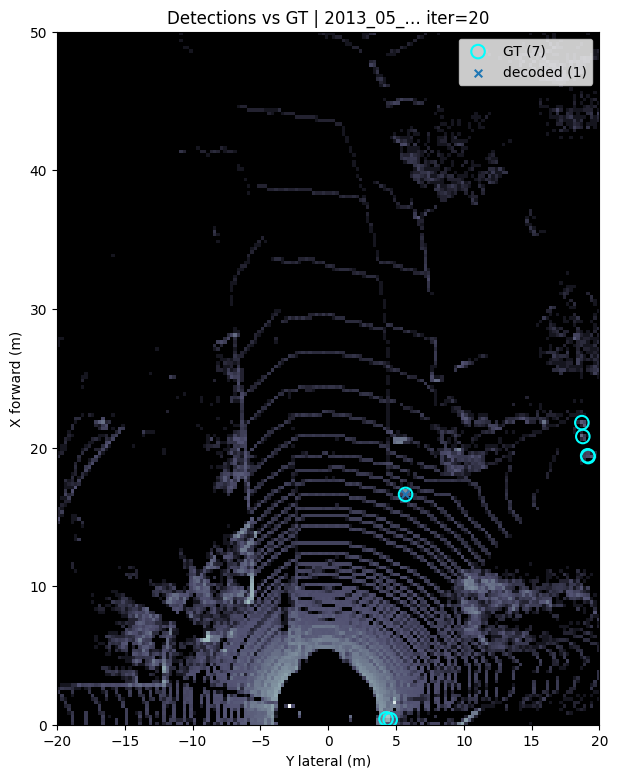

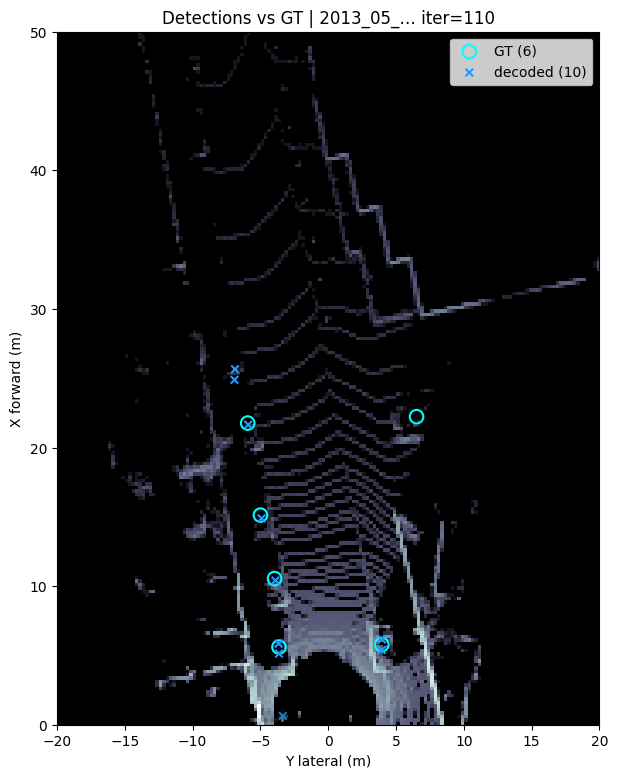

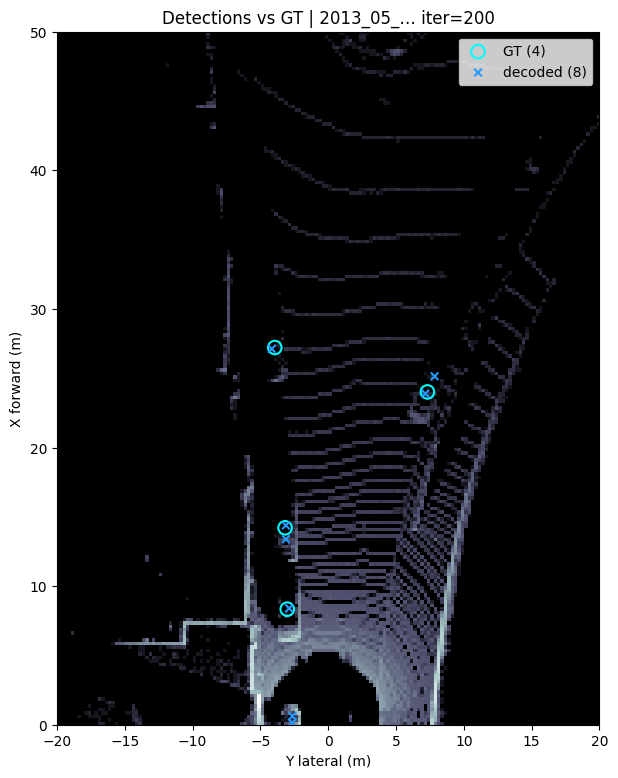

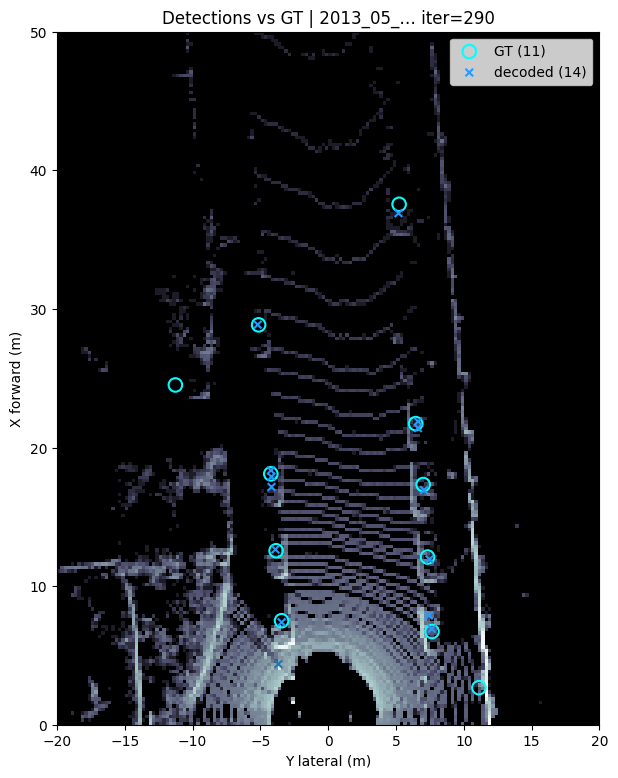

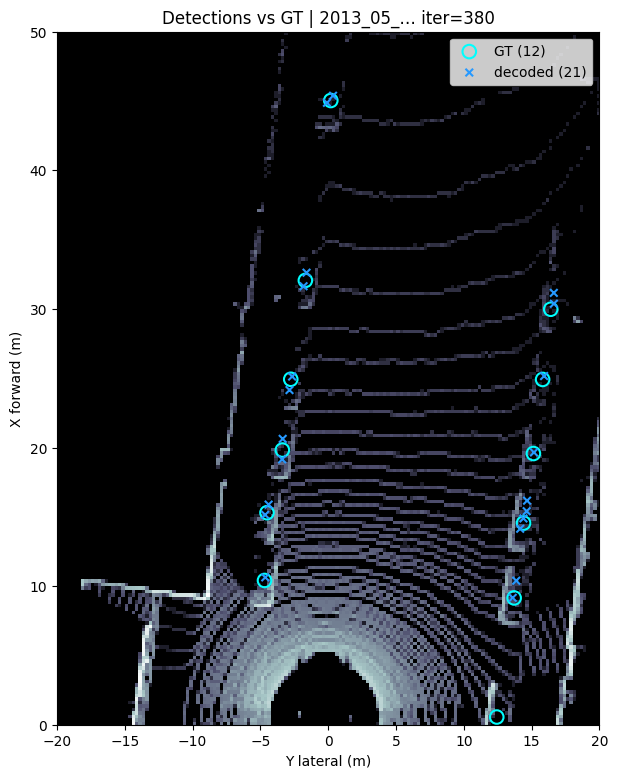

saved qualitative BEV frames -> docs/img


In [6]:
val_ds = Py123dDataset(split_names=["kitti360_val"]); val_frames = list(val_ds)
CACHE = stereo_cache_root(val_ds.data_root, matcher="igev")
stereo_cfg = StereoBEVConfig(img_backbone="yolo26", yolo_freeze=True)
model, input_fn = build_detector(MODEL, stereo_cache_root=CACHE, stereo_cfg=stereo_cfg)
model.load_state_dict(torch.load(CKPT, weights_only=True)["model"]); model.to(DEVICE).eval()
decoder = CenterPointDecoder(score_threshold=0.2)
for i, frame in enumerate(val_frames[20:400:90]):
    sample = frame.to_stereo_sample(load_images=False, point_mask=False)
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)                                   # inline
    utils.visualize_detections(sample, det,                                   # + save for slides
        save_path=str(FIGDIR / f"{MODEL}{TAG}_det_{i}.png"))
print("saved qualitative BEV frames ->", FIGDIR)

---
*Figures in `docs/img/`. Cross-model comparison: `confronto.ipynb`.*